# Handwritten Digit Classification — Multi-Model Benchmark

**Course:** NSP4 Machine Learning — Assignment 2
**Dataset:** UCI Optical Recognition of Handwritten Digits (1797 instances, 64 features, 10 classes)

This notebook trains five classification models on a single dataset, evaluates each on
six metrics, and persists the fitted pipelines for the Streamlit front-end (`app.py`).

**Workflow**
1. Load and inspect the dataset
2. Exploratory look at the features and class balance
3. Stratified train/test split
4. Train five classifiers inside scikit-learn pipelines
5. Evaluate on Accuracy, AUC, Precision, Recall, F1, MCC
6. Compare results and persist artifacts


## 1. Imports and configuration

In [1]:
import json
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.30
TARGET_COL = "digit_class"

# Paths are relative to the notebook location (model/), so artifacts land in
# model/saved/ and test_data.csv lands in the repository root.
SAVE_DIR = "saved"
ROOT = ".."

os.makedirs(SAVE_DIR, exist_ok=True)
print("scikit-learn ready | random_state =", RANDOM_STATE)

scikit-learn ready | random_state = 42


## 2. Load the dataset

The dataset ships with scikit-learn as the 1797-instance test partition of the original
UCI archive. Each 32x32 binary scan was divided into non-overlapping 4x4 blocks and the
number of "on" pixels in each block was counted, producing an 8x8 grid of integers in the
range 0-16. Flattened, that gives the 64 features.

In [2]:
bundle = load_digits(as_frame=True)
df = bundle.frame.rename(columns={"target": TARGET_COL})
feature_names = [col for col in df.columns if col != TARGET_COL]

print(f"Instances : {df.shape[0]}   (assignment minimum: 500)")
print(f"Features  : {len(feature_names)}   (assignment minimum: 12)")
print(f"Classes   : {sorted(df[TARGET_COL].unique())}")
print(f"Missing   : {int(df.isna().sum().sum())}")
df.head()

Instances : 1797   (assignment minimum: 500)
Features  : 64   (assignment minimum: 12)
Classes   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Missing   : 0


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,digit_class
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 3. Exploratory data analysis

In [3]:
print("Class distribution:")
print(df[TARGET_COL].value_counts().sort_index().to_string())

print("\nFeature value range:", int(df[feature_names].values.min()),
      "to", int(df[feature_names].values.max()))
df[feature_names[:8]].describe().round(2)

Class distribution:
digit_class
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180

Feature value range: 0 to 16


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7
count,1797.0,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00,1797.00
mean,0.0,0.30,5.20,11.84,11.85,5.78,1.36,0.13
std,0.0,0.91,4.75,4.25,4.29,5.67,3.33,1.04
min,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.0,0.00,1.00,10.00,10.00,0.00,0.00,0.00
50%,0.0,0.00,4.00,13.00,13.00,4.00,0.00,0.00
75%,0.0,0.00,9.00,15.00,15.00,11.00,0.00,0.00
max,0.0,8.00,16.00,16.00,16.00,16.00,16.00,15.00


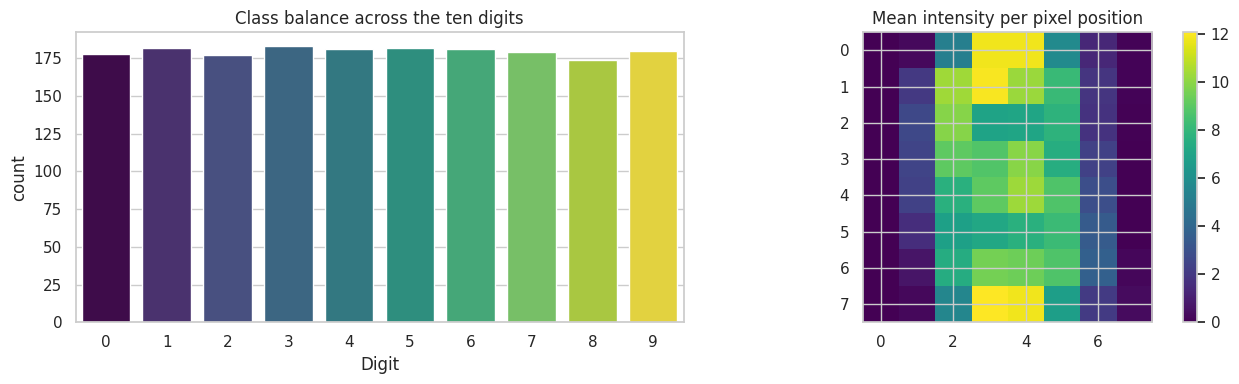

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x=df[TARGET_COL], hue=df[TARGET_COL], palette="viridis",
              legend=False, ax=axes[0])
axes[0].set_title("Class balance across the ten digits")
axes[0].set_xlabel("Digit")

pixel_means = df[feature_names].mean().values.reshape(8, 8)
im = axes[1].imshow(pixel_means, cmap="viridis")
axes[1].set_title("Mean intensity per pixel position")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

The classes are near-uniform, so plain accuracy is not misleading here and macro
averaging treats every digit fairly. The intensity map shows the border pixels are close
to constant zero — that near-zero variance is exactly what forces the `var_smoothing`
adjustment on Gaussian Naive Bayes later.

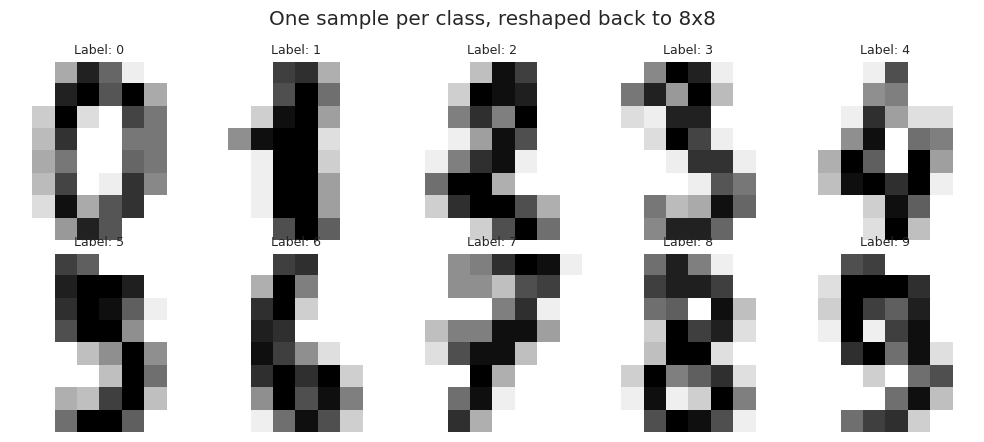

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in zip(range(10), axes.ravel()):
    sample = df[df[TARGET_COL] == digit][feature_names].iloc[0].values.reshape(8, 8)
    ax.imshow(sample, cmap="gray_r")
    ax.set_title(f"Label: {digit}", fontsize=9)
    ax.axis("off")
plt.suptitle("One sample per class, reshaped back to 8x8")
plt.tight_layout()
plt.show()

## 4. Train / test split

A stratified 70/30 split keeps the class proportions identical in both folds. Every model
below sees exactly the same training rows and is scored on exactly the same held-out rows,
which is what makes the comparison table meaningful.

In [6]:
X = df[feature_names]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set : {X_train.shape[0]} rows x {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]} rows x {X_test.shape[1]} features")
print("\nStratification check (proportion per class):")
print(pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index().round(4),
    "test": y_test.value_counts(normalize=True).sort_index().round(4),
}))

Training set : 1257 rows x 64 features
Test set     : 540 rows x 64 features

Stratification check (proportion per class):
              train    test
digit_class                
0            0.0986  0.1000
1            0.1010  0.1019
2            0.0986  0.0981
3            0.1018  0.1019
4            0.1010  0.1000
5            0.1010  0.1019
6            0.1010  0.1000
7            0.0994  0.1000
8            0.0971  0.0963
9            0.1002  0.1000


## 5. Define the five models

Scaling is placed **inside** each `Pipeline` rather than applied globally. This prevents
training statistics from leaking into the test fold, and it means the Streamlit app can
hand a raw CSV straight to `.predict()` with no manual preprocessing.

Logistic Regression and kNN need standardised features because they are sensitive to
magnitude and distance respectively. Trees and Gaussian Naive Bayes are unaffected by
monotonic rescaling, so they are fitted on raw values.

In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, C=0.5,
                                   random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("clf", DecisionTreeClassifier(criterion="entropy", max_depth=12,
                                       min_samples_leaf=3,
                                       random_state=RANDOM_STATE)),
    ]),
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5, weights="distance",
                                     metric="euclidean")),
    ]),
    "Naive Bayes": Pipeline([
        ("clf", GaussianNB(var_smoothing=1e-2)),
    ]),
    "Random Forest (Ensemble)": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                       random_state=RANDOM_STATE)),
    ]),
}

for name, pipe in models.items():
    steps = " -> ".join(step for step, _ in pipe.steps)
    print(f"{name:26s} : {steps}")

Logistic Regression        : scaler -> clf
Decision Tree              : clf
kNN                        : scaler -> clf
Naive Bayes                : clf
Random Forest (Ensemble)   : clf


## 6. Evaluation metrics

Because the task is multi-class, Precision, Recall and F1 are **macro-averaged** — each
digit contributes equally regardless of how many samples it has. AUC is computed
**one-vs-rest** from the predicted probability matrix. MCC handles multi-class natively
and is the strictest of the six, since it only scores well when all ten classes are
predicted well.

In [8]:
def evaluate(pipeline, X_eval, y_eval):
    """Return the six required evaluation metrics for a fitted pipeline."""
    y_pred = pipeline.predict(X_eval)
    y_proba = pipeline.predict_proba(X_eval)

    return {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "AUC": roc_auc_score(y_eval, y_proba, multi_class="ovr", average="macro"),
        "Precision": precision_score(y_eval, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_eval, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_eval, y_pred),
    }

print("Metric function defined.")

Metric function defined.


## 7. Train and evaluate every model

In [9]:
results = []
predictions = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    scores = evaluate(pipeline, X_test, y_test)

    predictions[name] = pipeline.predict(X_test)
    results.append({"ML Model Name": name, **scores})

    print(f"{name:26s} | acc={scores['Accuracy']:.4f}  "
          f"f1={scores['F1']:.4f}  mcc={scores['MCC']:.4f}")

metrics_df = pd.DataFrame(results).round(4)
print("\nAll models trained.")

Logistic Regression        | acc=0.9796  f1=0.9796  mcc=0.9774
Decision Tree              | acc=0.8204  f1=0.8209  mcc=0.8008
kNN                        | acc=0.9722  f1=0.9720  mcc=0.9692
Naive Bayes                | acc=0.9130  f1=0.9131  mcc=0.9035


Random Forest (Ensemble)   | acc=0.9685  f1=0.9682  mcc=0.9652

All models trained.


### Comparison table

This is the table reproduced in the README and the submitted PDF.

In [10]:
metrics_df.style.highlight_max(
    subset=["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"],
    color="#b7e4c7"
).format(precision=4)

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9796,0.9991,0.9797,0.9795,0.9796,0.9774
1,Decision Tree,0.8204,0.9240,0.8258,0.8201,0.8209,0.8008
2,kNN,0.9722,0.9937,0.9725,0.9720,0.9720,0.9692
3,Naive Bayes,0.9130,0.9887,0.9151,0.9130,0.9131,0.9035
4,Random Forest (Ensemble),0.9685,0.9992,0.9698,0.9681,0.9682,0.9652


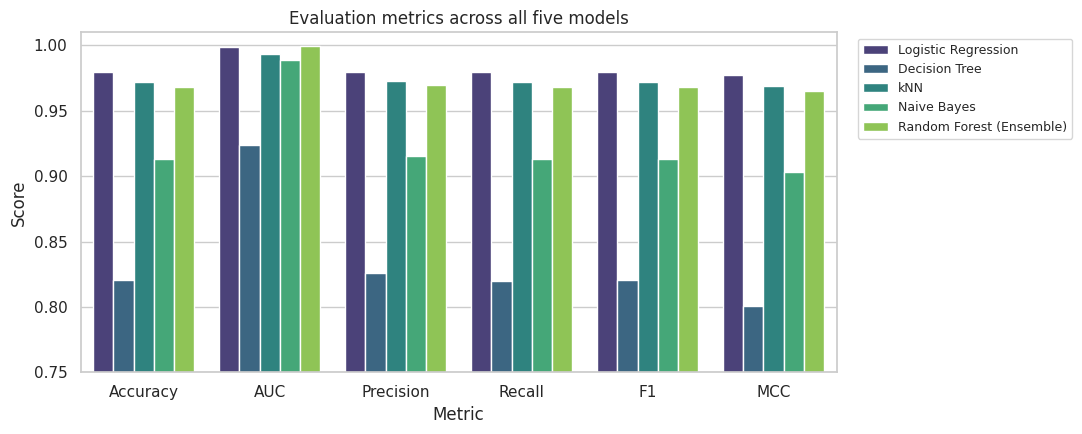

In [11]:
melted = metrics_df.melt(id_vars="ML Model Name", var_name="Metric",
                         value_name="Score")

plt.figure(figsize=(11, 4.5))
sns.barplot(data=melted, x="Metric", y="Score", hue="ML Model Name",
            palette="viridis")
plt.ylim(0.75, 1.01)
plt.title("Evaluation metrics across all five models")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Confusion matrices

The confusion matrix is where the multi-class setting earns its keep — it shows *which*
digits each model confuses, not merely how often it is wrong.

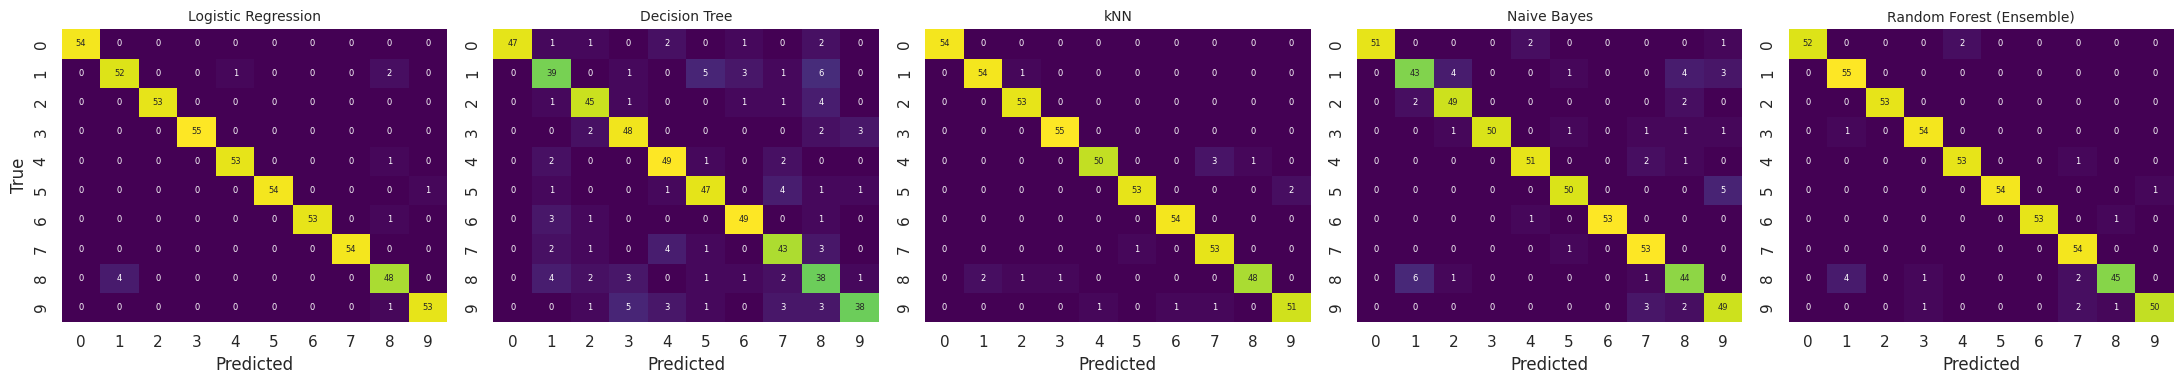

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=False,
                ax=ax, annot_kws={"size": 6})
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if ax is axes[0] else "")

plt.tight_layout()
plt.show()

### Per-class report for the best model

In [13]:
best_model_name = metrics_df.loc[metrics_df["F1"].idxmax(), "ML Model Name"]
print(f"Best macro-F1: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], zero_division=0))

Best macro-F1: Logistic Regression

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.93      0.95      0.94        55
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        55
           4       0.98      0.98      0.98        54
           5       1.00      0.98      0.99        55
           6       1.00      0.98      0.99        54
           7       1.00      1.00      1.00        54
           8       0.91      0.92      0.91        52
           9       0.98      0.98      0.98        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



## 9. Stability check with cross-validation

The gap between the top models on a single split is only a handful of test samples wide.
A 5-fold cross-validation on the training set indicates whether those differences are real
or an artifact of one particular split.

In [14]:
cv_rows = []
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=5,
                             scoring="f1_macro", n_jobs=-1)
    cv_rows.append({
        "ML Model Name": name,
        "CV mean F1": scores.mean(),
        "CV std": scores.std(),
        "Hold-out F1": metrics_df.loc[
            metrics_df["ML Model Name"] == name, "F1"].values[0],
    })

pd.DataFrame(cv_rows).round(4)

,ML Model Name,CV mean F1,CV std,Hold-out F1
0,Logistic Regression,0.9664,0.0092,0.9796
1,Decision Tree,0.8501,0.0203,0.8209
2,kNN,0.9688,0.0169,0.9720
3,Naive Bayes,0.9162,0.0103,0.9131
4,Random Forest (Ensemble),0.9736,0.0066,0.9682


The standard deviations overlap for the leading models, which supports the cautious
conclusion in the README: Logistic Regression, kNN and Random Forest form a statistically
indistinguishable leading group, and the clear, robust finding is the *tier ordering*
rather than the exact winner.

## 10. Persist artifacts

Saved with `compress=3` to keep the repository small enough for a comfortable
Streamlit Community Cloud cold start.

In [15]:
for name, pipeline in models.items():
    slug = name.split(" (")[0].lower().replace(" ", "_")
    path = os.path.join(SAVE_DIR, f"{slug}.joblib")
    joblib.dump(pipeline, path, compress=3)
    print(f"saved {path:45s} ({os.path.getsize(path) / 1024:.1f} KB)")

metrics_df.to_csv(os.path.join(SAVE_DIR, "metrics.csv"), index=False)

with open(os.path.join(SAVE_DIR, "feature_names.json"), "w") as fh:
    json.dump({"features": feature_names, "target": TARGET_COL}, fh)

test_frame = X_test.copy()
test_frame[TARGET_COL] = y_test
test_frame.to_csv(os.path.join(ROOT, "test_data.csv"), index=False)

print(f"\nsaved metrics.csv, feature_names.json")
print(f"saved ../test_data.csv ({test_frame.shape[0]} rows) for the Streamlit app")

saved saved/logistic_regression.joblib              (7.2 KB)
saved saved/decision_tree.joblib                    (6.1 KB)
saved saved/knn.joblib                              (121.3 KB)
saved saved/naive_bayes.joblib                      (7.1 KB)


saved saved/random_forest.joblib                    (2879.9 KB)

saved metrics.csv, feature_names.json
saved ../test_data.csv (540 rows) for the Streamlit app


## 11. Summary

| Model | Key takeaway |
|---|---|
| Logistic Regression | Best on five of six metrics. After block-averaging the classes are close to linearly separable, so a small linear model has enough capacity with no room to overfit. |
| Decision Tree | Weakest by a wide margin. Digit identity is spread across the whole pixel grid, so axis-aligned splits on single correlated pixels give a brittle, high-variance model. |
| kNN | Essentially tied with the leader. Same-class digits produce near-identical vectors, so Euclidean distance is genuinely meaningful — but it stores every training row and is slowest to serve. |
| Naive Bayes | Mid-pack. Neighbouring pixels are strongly correlated, so the conditional-independence assumption over-counts evidence. Its AUC far exceeds its accuracy: good ranking, over-confident probabilities. |
| Random Forest | Roughly 15 F1 points above the single tree — the clearest demonstration of variance reduction through ensembling in this experiment, and the best-calibrated probabilities (highest AUC). |

**Next step:** run `streamlit run app.py` from the repository root to launch the
interactive front-end backed by the models saved above.